# Exploratory Data Analysis — Disaster Recovery Cost Forecasting
**Goal:** Understand the distribution, relationships, and structure of the merged FEMA dataset so we can make informed feature engineering decisions.

**Analysis levels:**
1. Univariate — distribution of each individual variable  
2. Bivariate — relationships between features and the target (`totalObligatedAmountPa`)  
3. Multivariate — interactions between multiple features simultaneously

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Load merged dataset (date columns already parsed by clean_data.py)
DATA_PATH = Path("../data/processed/merged.parquet")
df = pd.read_parquet(DATA_PATH, engine="pyarrow")

print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
df.head()


Shape: (4812, 27)

Column types:
disasterNumber                         int64
state                                    str
declarationType                          str
declarationDate               datetime64[ns]
fyDeclared                             int64
incidentType                             str
incidentBeginDate             datetime64[ns]
incidentEndDate               datetime64[ns]
region                                 int64
paProgramDeclared                       bool
iaProgramDeclared                       bool
hmProgramDeclared                       bool
tribalRequest                           bool
numDesignatedAreas                     int64
totalNumberIaApproved                float64
totalAmountIhpApproved               float64
totalAmountHaApproved                float64
totalAmountOnaApproved               float64
totalObligatedAmountPa               float64
totalObligatedAmountCatAb            float64
totalObligatedAmountCatC2g           float64
totalObligatedAmountHm

,disasterNumber,state,declarationType,declarationDate,fyDeclared,incidentType,incidentBeginDate,incidentEndDate,region,paProgramDeclared,iaProgramDeclared,hmProgramDeclared,tribalRequest,numDesignatedAreas,totalNumberIaApproved,totalAmountIhpApproved,totalAmountHaApproved,totalAmountOnaApproved,totalObligatedAmountPa,totalObligatedAmountCatAb,totalObligatedAmountCatC2g,totalObligatedAmountHmgp,projectAmount,federalShareObligated,totalObligated,mitigationAmount,numProjects
0,1,GA,DR,1953-05-02,1953,Tornado,1953-05-02,1953-05-02,4,True,True,True,False,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2,TX,DR,1953-05-15,1953,Tornado,1953-05-15,1953-05-15,6,True,True,True,False,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,3,LA,DR,1953-05-29,1953,Flood,1953-05-29,1953-05-29,6,True,True,True,False,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,4,MI,DR,1953-06-02,1953,Tornado,1953-06-02,1953-06-02,5,True,True,True,False,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,5,MT,DR,1953-06-06,1953,Flood,1953-06-06,1953-06-06,8,True,True,True,False,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [21]:
#count the number of null values in each column
print(f"\nNull values per column:\n{df.isnull().sum()}")


Null values per column:
disasterNumber                0
state                         0
declarationType               0
declarationDate               0
fyDeclared                    0
incidentType                  0
incidentBeginDate             0
incidentEndDate               0
region                        0
paProgramDeclared             0
iaProgramDeclared             0
hmProgramDeclared             0
tribalRequest                 0
numDesignatedAreas            0
totalNumberIaApproved         0
totalAmountIhpApproved        0
totalAmountHaApproved         0
totalAmountOnaApproved        0
totalObligatedAmountPa        0
totalObligatedAmountCatAb     0
totalObligatedAmountCatC2g    0
totalObligatedAmountHmgp      0
projectAmount                 0
federalShareObligated         0
totalObligated                0
mitigationAmount              0
numProjects                   0
dtype: int64


In [22]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
disasterNumber,"4,812.00",NaN,NaN,NaN,"2,779.71",1.00,"1,393.75","2,694.50","4,292.25","5,628.00","1,646.32"
state,4812,59,CA,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
declarationType,4812,3,DR,2568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
declarationDate,4812,NaN,NaN,NaN,2003-10-23 22:53:16.009975040,1953-05-02 00:00:00,1996-03-19 00:00:00,2007-07-16 00:00:00,2017-09-15 18:00:00,2026-04-11 00:00:00,NaN
fyDeclared,"4,812.00",NaN,NaN,NaN,"2,003.47","1,953.00","1,996.00","2,007.00","2,017.00","2,026.00",17.30
incidentType,4812,26,Fire,1720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incidentBeginDate,4812,NaN,NaN,NaN,2003-10-03 10:00:17.955112320,1953-05-02 00:00:00,1996-03-14 00:00:00,2007-07-07 00:00:00,2017-09-07 00:00:00,2026-04-11 00:00:00,NaN
incidentEndDate,4812,NaN,NaN,NaN,2003-11-26 18:05:41.147132288,1953-05-02 00:00:00,1996-03-19 00:00:00,2007-07-16 00:00:00,2017-09-20 06:00:00,2026-04-11 00:00:00,NaN
region,"4,812.00",NaN,NaN,NaN,6.13,1.00,4.00,6.00,9.00,10.00,2.68
paProgramDeclared,4812,1,True,4812,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df.isnull().sum()

disasterNumber                0
state                         0
declarationType               0
declarationDate               0
fyDeclared                    0
incidentType                  0
incidentBeginDate             0
incidentEndDate               0
region                        0
paProgramDeclared             0
iaProgramDeclared             0
hmProgramDeclared             0
tribalRequest                 0
numDesignatedAreas            0
totalNumberIaApproved         0
totalAmountIhpApproved        0
totalAmountHaApproved         0
totalAmountOnaApproved        0
totalObligatedAmountPa        0
totalObligatedAmountCatAb     0
totalObligatedAmountCatC2g    0
totalObligatedAmountHmgp      0
projectAmount                 0
federalShareObligated         0
totalObligated                0
mitigationAmount              0
numProjects                   0
dtype: int64

In [24]:
# Quick data quality summary
print("=== Missing Values ===")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing if not missing.empty else "No missing values")

print("\n=== Descriptive Statistics (numeric) ===")
df.describe(include="number").T

=== Missing Values ===
No missing values

=== Descriptive Statistics (numeric) ===


,count,mean,std,min,25%,50%,75%,max
disasterNumber,"4,812.00","2,779.71","1,646.32",1.00,"1,393.75","2,694.50","4,292.25","5,628.00"
fyDeclared,"4,812.00","2,003.47",17.30,"1,953.00","1,996.00","2,007.00","2,017.00","2,026.00"
region,"4,812.00",6.13,2.68,1.00,4.00,6.00,9.00,10.00
numDesignatedAreas,"4,812.00",13.41,25.27,1.00,1.00,3.00,14.00,443.00
totalNumberIaApproved,"4,812.00","2,318.86","28,131.86",0.00,0.00,0.00,0.00,"774,691.00"
totalAmountIhpApproved,"4,812.00","7,618,172.15","97,583,581.64",0.00,0.00,0.00,0.00,"5,247,169,458.98"
totalAmountHaApproved,"4,812.00","4,594,194.12","67,198,930.99",0.00,0.00,0.00,0.00,"3,745,182,194.99"
totalAmountOnaApproved,"4,812.00","3,023,978.03","34,424,068.59",0.00,0.00,0.00,0.00,"1,501,987,263.99"
totalObligatedAmountPa,"4,812.00","57,184,430.36","799,370,473.52","-23,499,530.30",0.00,"239,505.83","5,385,216.64","35,587,839,789.10"
totalObligatedAmountCatAb,"4,812.00","31,019,567.01","416,640,679.38","-23,709,417.56",0.00,"10,304.54","1,010,978.72","16,917,062,024.27"


---
## 1. Univariate Analysis
Distribution of each variable individually — helps identify skewness, outliers, and class imbalance.

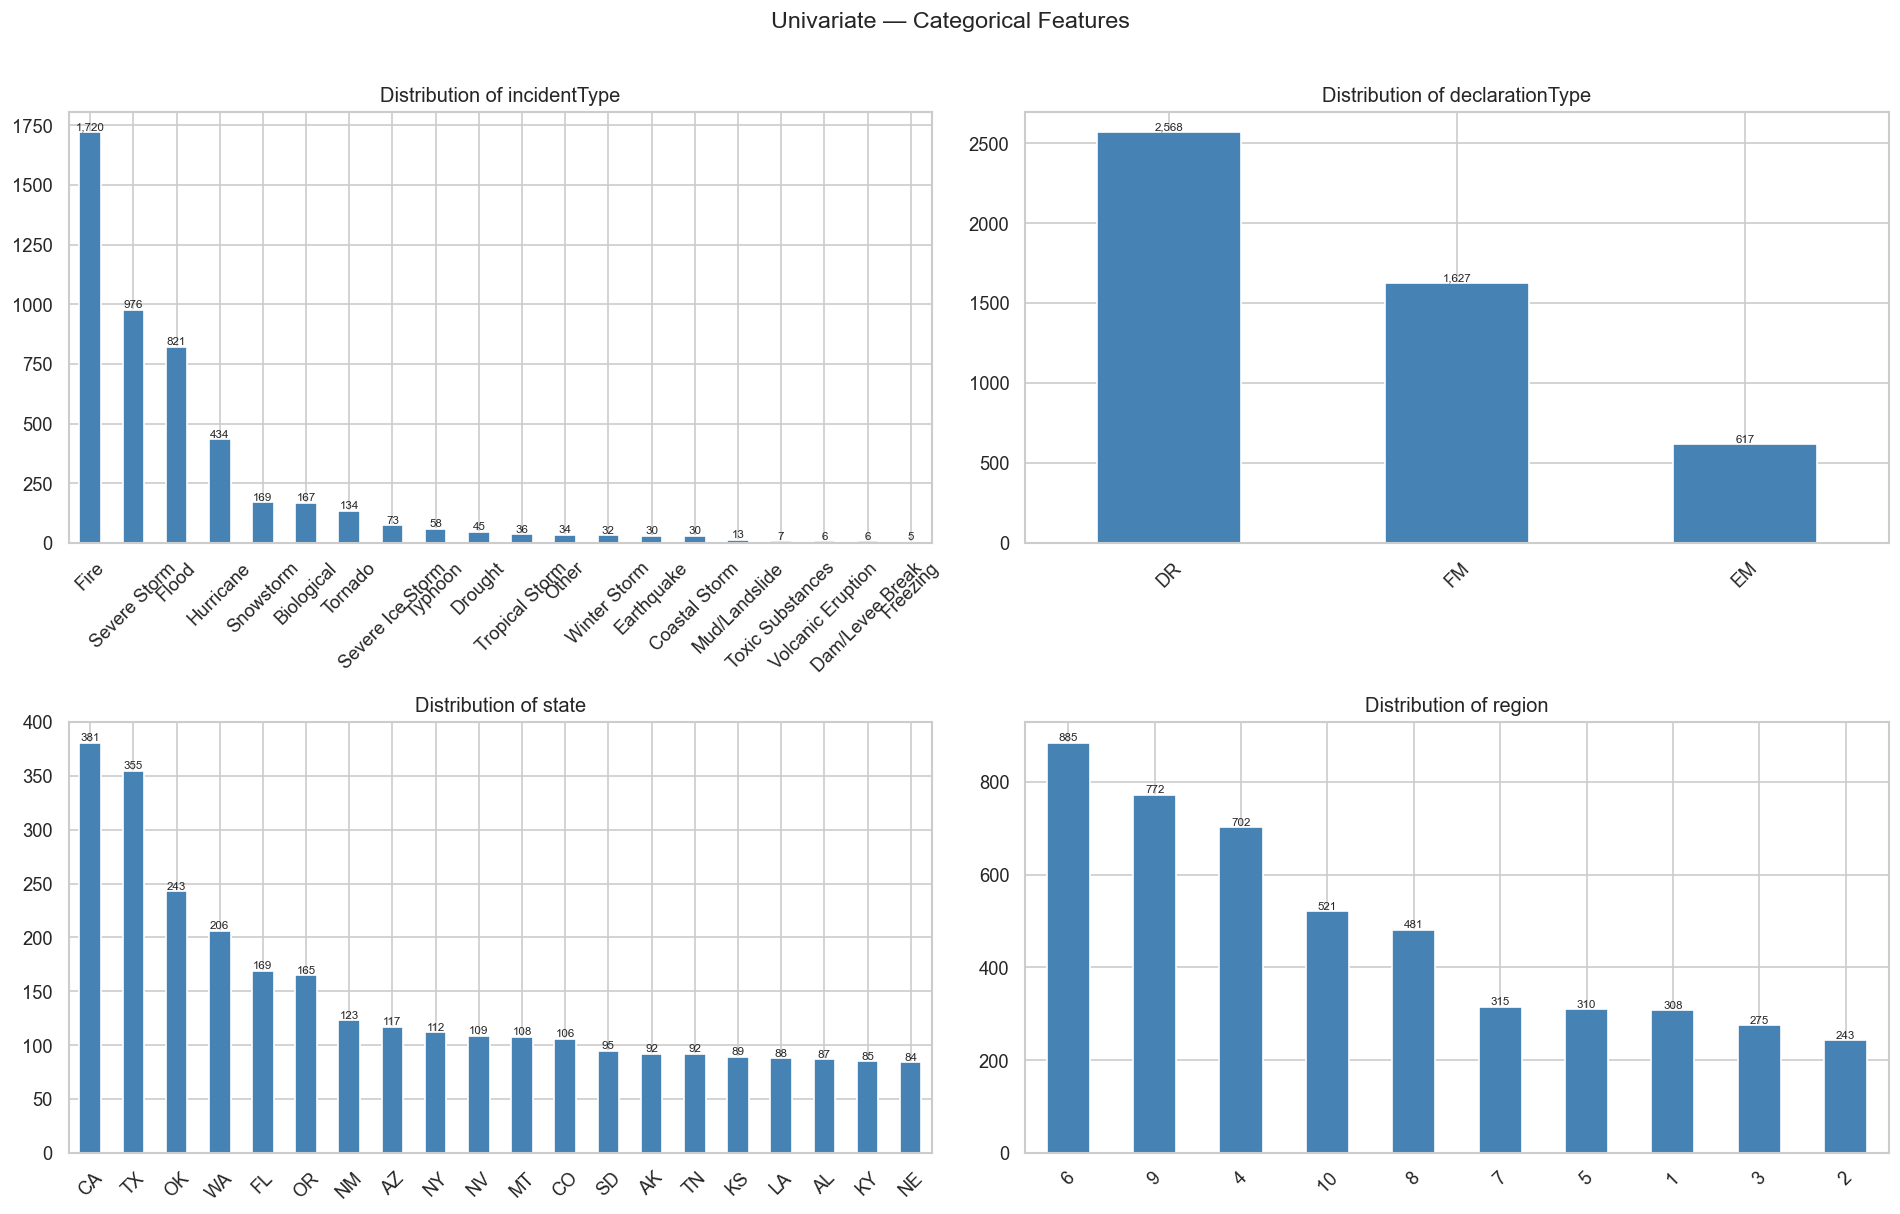

In [25]:
# ── 1a. Categorical columns ────────────────────────────────────────────────
cat_cols = ["incidentType", "declarationType", "state", "region"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flat, cat_cols):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    counts = df[col].value_counts().head(20)
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribution of {col}", fontsize=12)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=7)

plt.suptitle("Univariate — Categorical Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

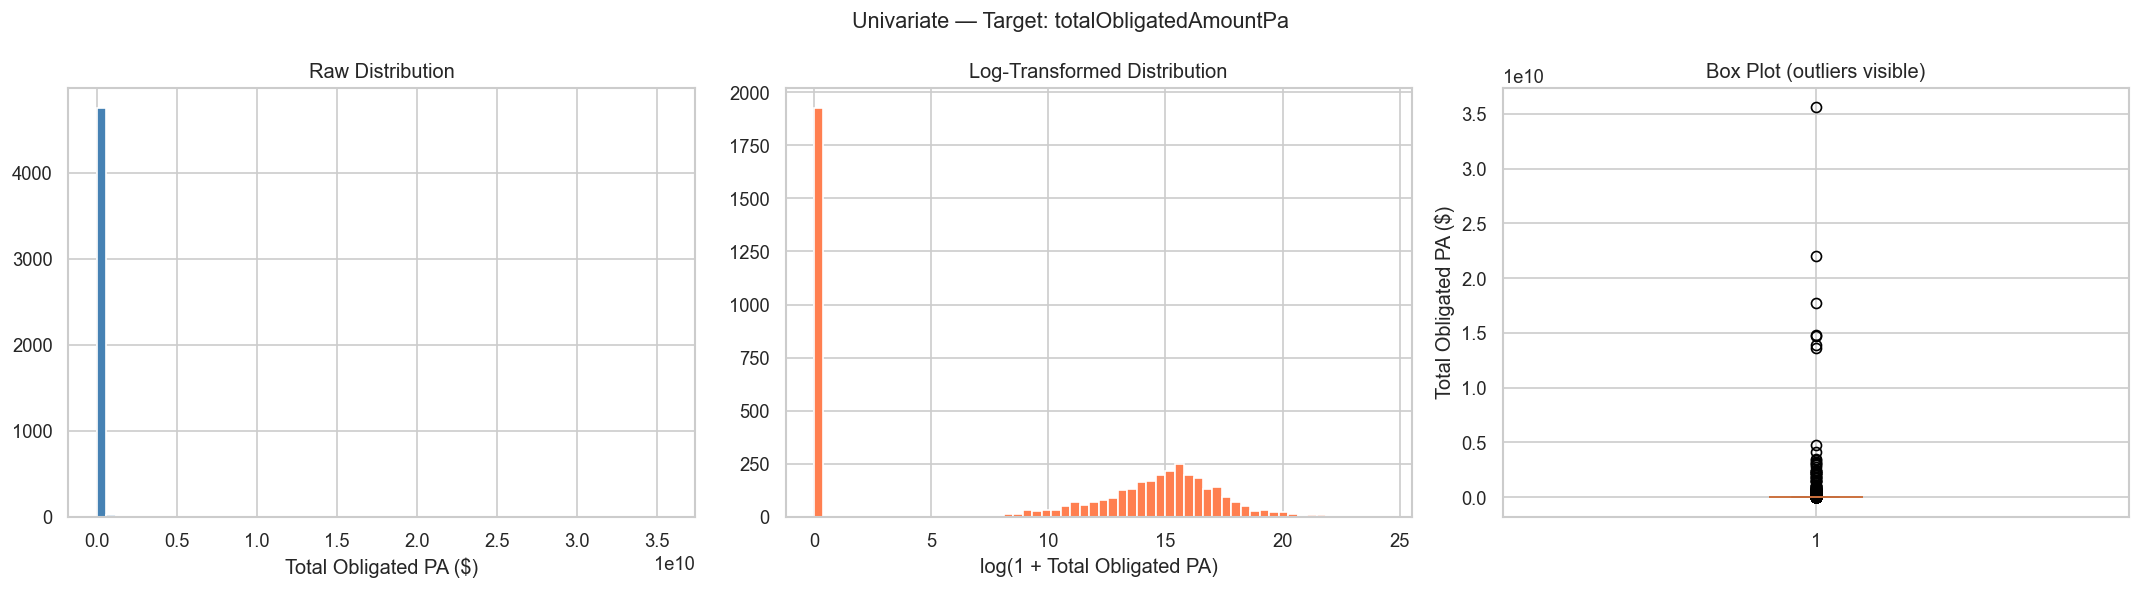


Target stats:
count             4,812
mean         57,184,430
std         799,370,474
min         -23,499,530
25%                   0
50%             239,506
75%           5,385,217
max      35,587,839,789
Name: totalObligatedAmountPa, dtype: str

Zero-value rows: 1923 / 4812
Null rows:       0 / 4812


In [26]:
# ── 1b. Target variable distribution ──────────────────────────────────────
target = "totalObligatedAmountPa"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw distribution
axes[0].hist(df[target].dropna(), bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Raw Distribution")
axes[0].set_xlabel("Total Obligated PA ($)")

# Log-transformed (disaster cost data is typically log-normal)
log_vals = np.log1p(df[target].dropna().clip(lower=0))
axes[1].hist(log_vals, bins=60, color="coral", edgecolor="white")
axes[1].set_title("Log-Transformed Distribution")
axes[1].set_xlabel("log(1 + Total Obligated PA)")

# Box plot to show outliers
axes[2].boxplot(df[target].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="lightblue"))
axes[2].set_title("Box Plot (outliers visible)")
axes[2].set_ylabel("Total Obligated PA ($)")

plt.suptitle(f"Univariate — Target: {target}", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nTarget stats:\n{df[target].describe().apply('{:,.0f}'.format)}")
print(f"\nZero-value rows: {(df[target] == 0).sum()} / {len(df)}")
print(f"Null rows:       {df[target].isnull().sum()} / {len(df)}")

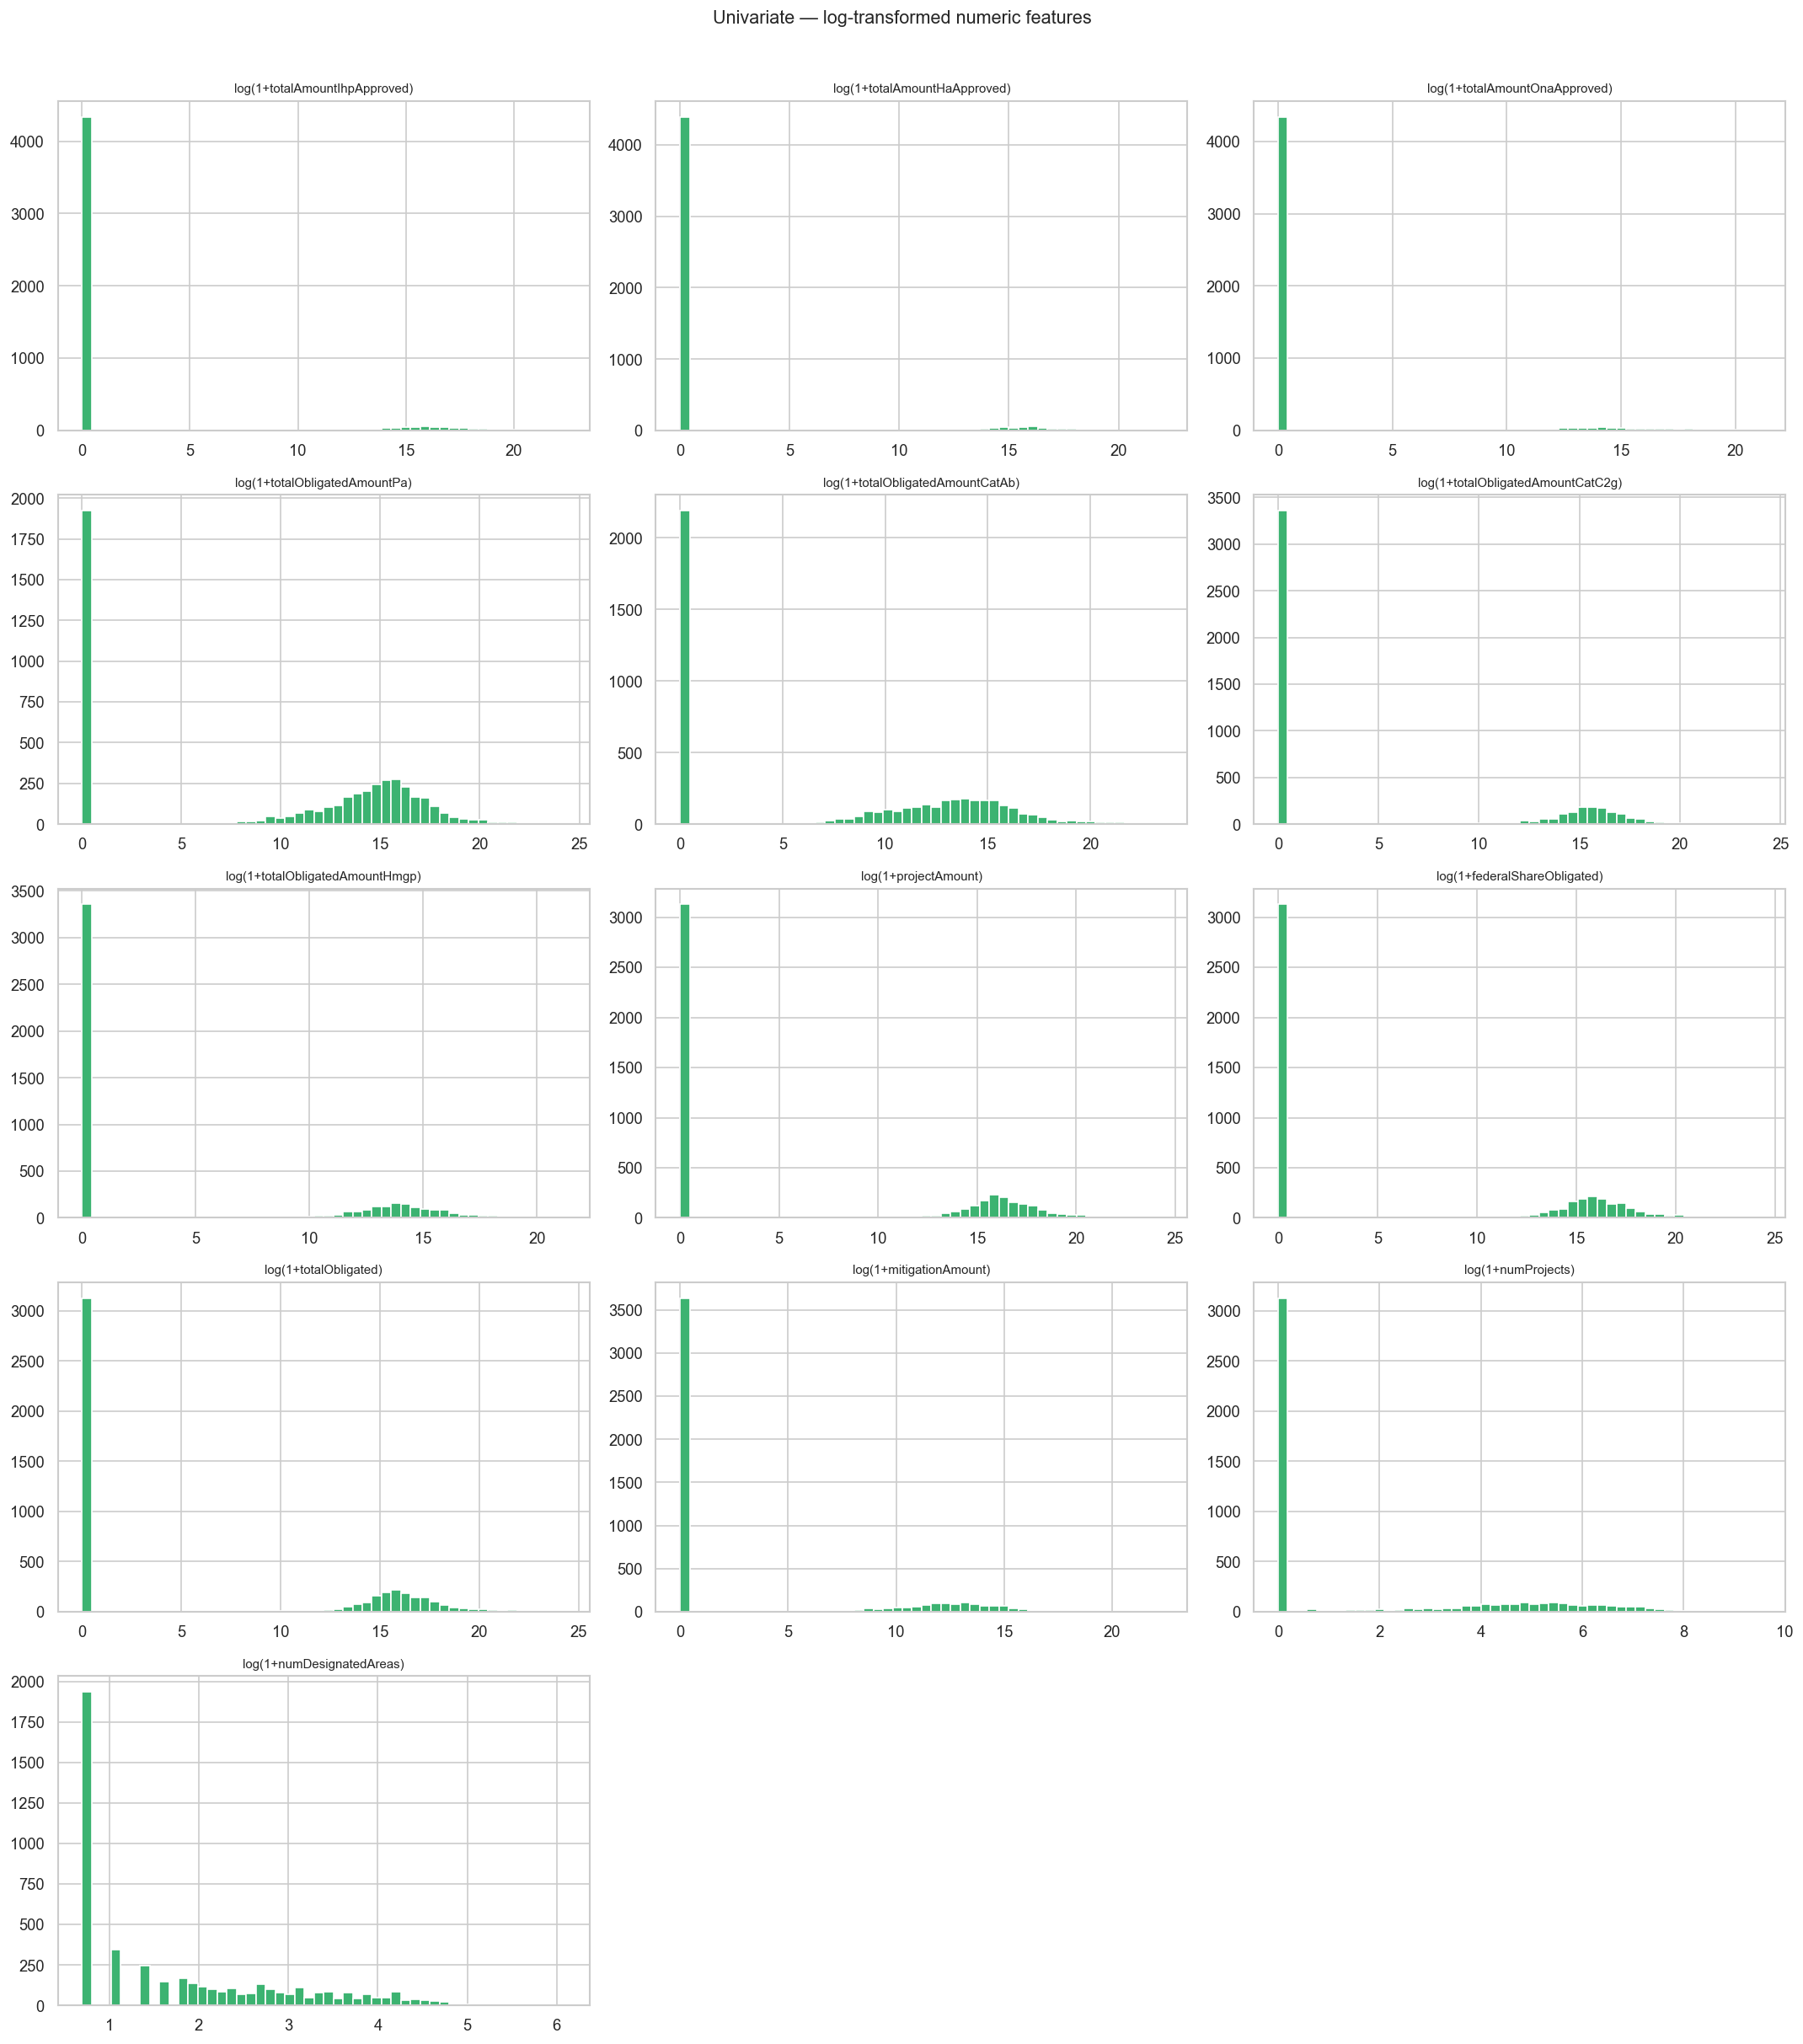

In [27]:
# ── 1c. All monetary/numeric feature distributions ─────────────────────────
money_cols = [
    "totalAmountIhpApproved", "totalAmountHaApproved", "totalAmountOnaApproved",
    "totalObligatedAmountPa", "totalObligatedAmountCatAb", "totalObligatedAmountCatC2g",
    "totalObligatedAmountHmgp", "projectAmount", "federalShareObligated",
    "totalObligated", "mitigationAmount", "numProjects", "numDesignatedAreas",
]
money_cols = [c for c in money_cols if c in df.columns]

n = len(money_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows * 4))
for ax, col in zip(axes.flat, money_cols):
    vals = np.log1p(df[col].clip(lower=0).dropna())
    ax.hist(vals, bins=50, color="mediumseagreen", edgecolor="white")
    ax.set_title(f"log(1+{col})", fontsize=9)
    ax.set_xlabel("")

# Hide unused axes
for ax in axes.flat[n:]:
    ax.set_visible(False)

plt.suptitle("Univariate — log-transformed numeric features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

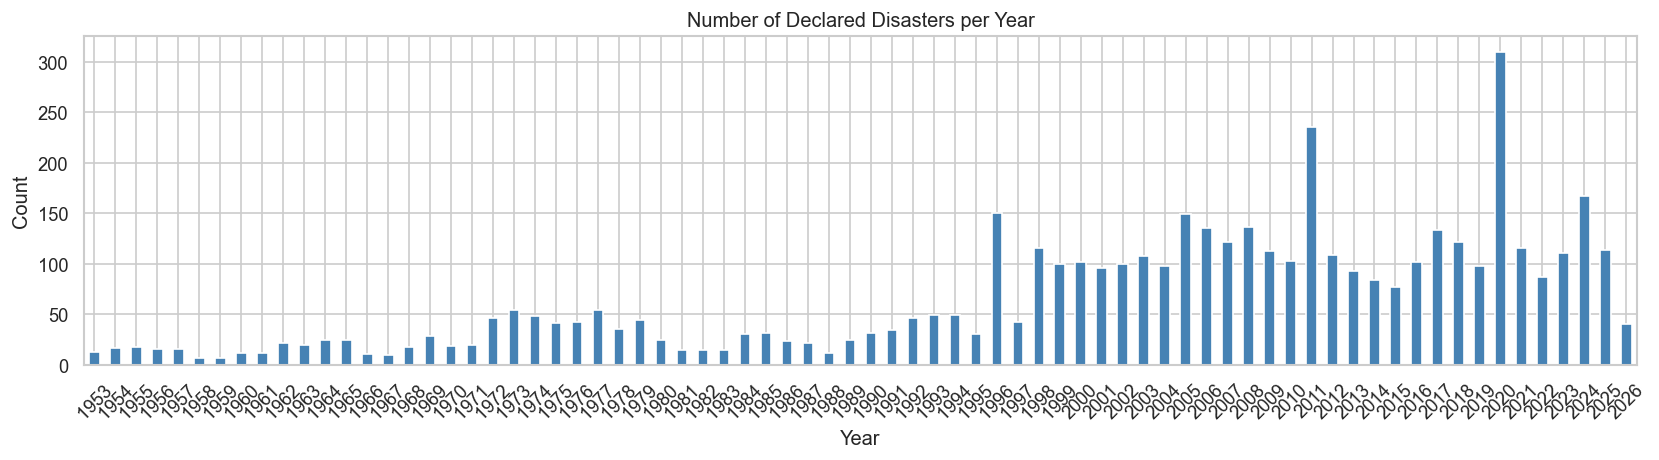

In [28]:
# ── 1d. Disasters over time ────────────────────────────────────────────────
if "declarationDate" in df.columns:
    yearly = df.groupby(df["declarationDate"].dt.year).size()
    fig, ax = plt.subplots(figsize=(14, 4))
    yearly.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title("Number of Declared Disasters per Year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

---
## 2. Bivariate Analysis
Relationship between each feature and the target variable (`totalObligatedAmountPa`).

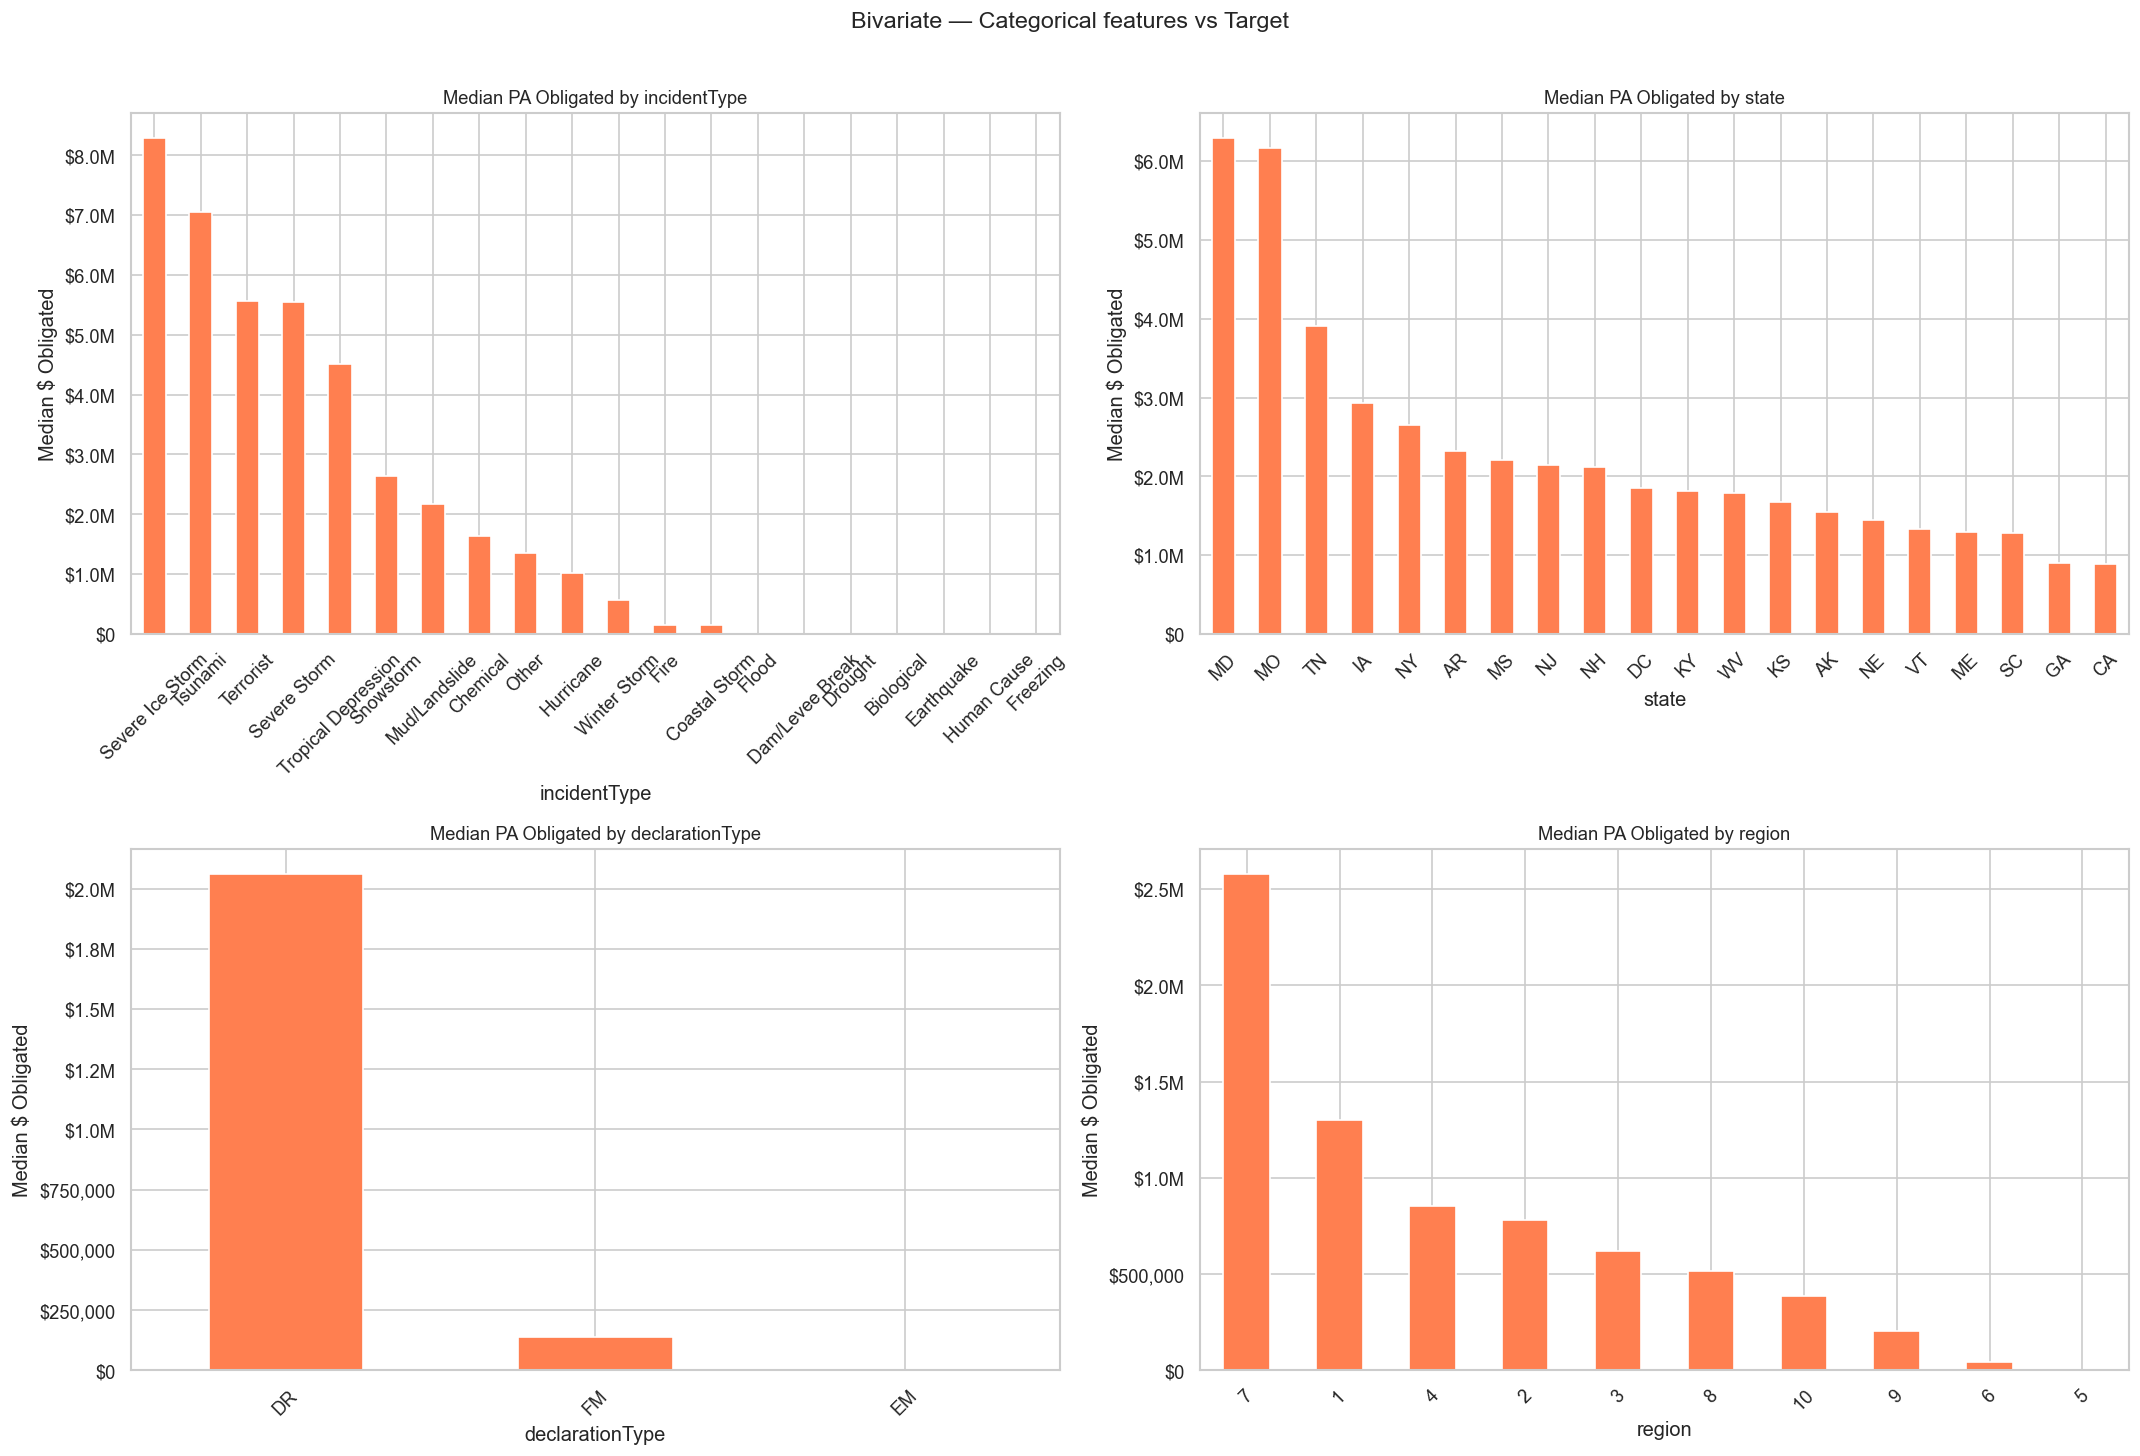

In [29]:
# ── 2a. Target vs categorical features (median PA cost per category) ────────
cat_cols = ["incidentType", "state", "declarationType", "region"]
cat_cols = [c for c in cat_cols if c in df.columns]
target = "totalObligatedAmountPa"

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, col in zip(axes.flat, cat_cols):
    medians = (
        df.groupby(col)[target]
        .median()
        .sort_values(ascending=False)
        .head(20)
    )
    medians.plot(kind="bar", ax=ax, color="coral", edgecolor="white")
    ax.set_title(f"Median PA Obligated by {col}", fontsize=11)
    ax.set_ylabel("Median $ Obligated")
    ax.tick_params(axis="x", rotation=45)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x:,.0f}")
    )

plt.suptitle("Bivariate — Categorical features vs Target", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

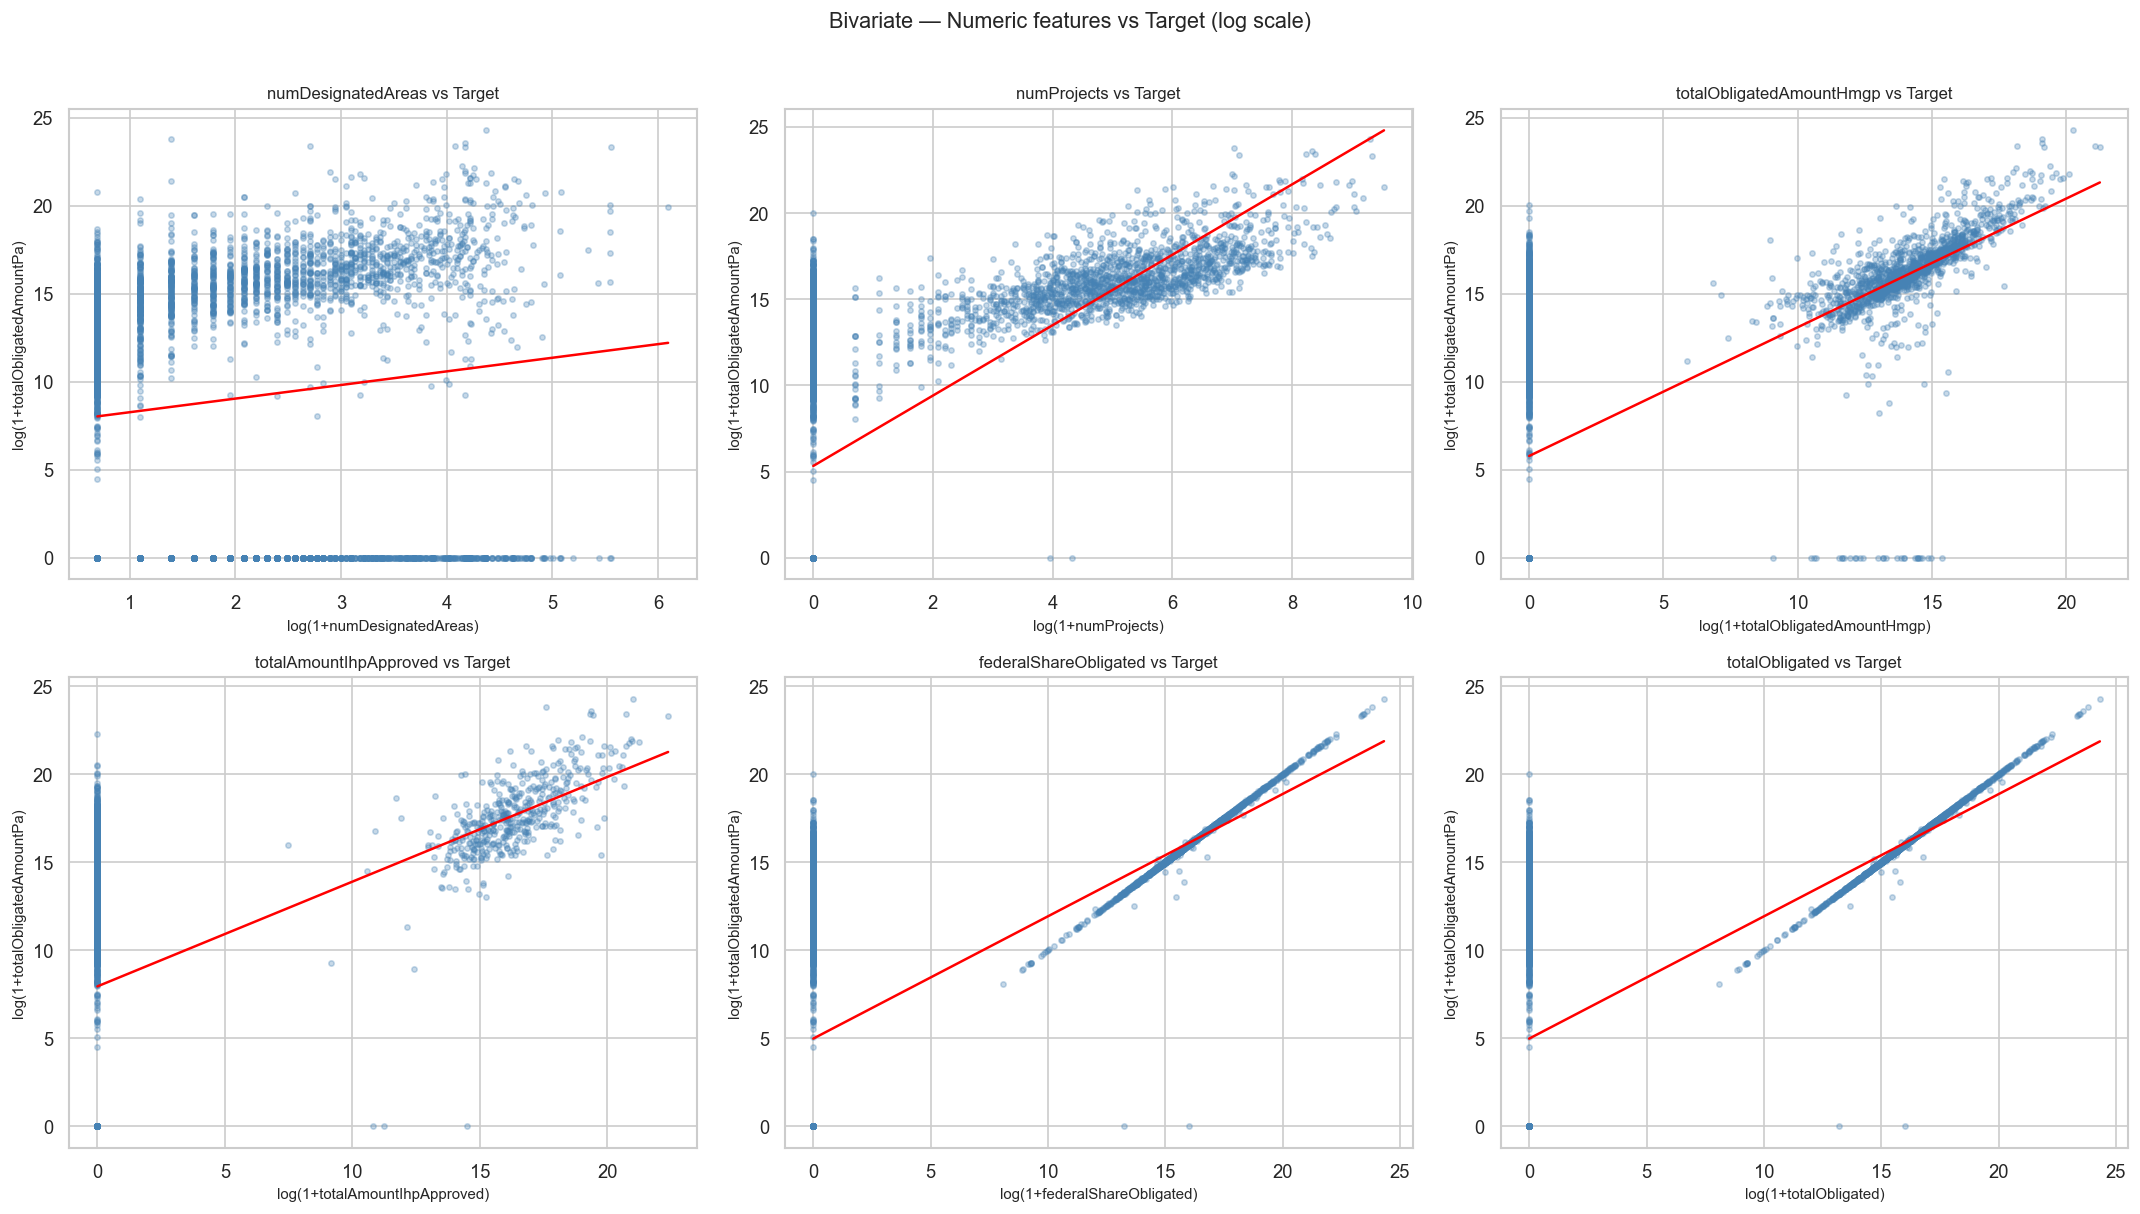

In [30]:
# ── 2b. Target vs numeric features (scatter plots with log scale) ──────────
numeric_features = [
    "numDesignatedAreas", "numProjects", "totalObligatedAmountHmgp",
    "totalAmountIhpApproved", "federalShareObligated", "totalObligated",
]
numeric_features = [c for c in numeric_features if c in df.columns]

n = len(numeric_features)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, rows * 5))
for ax, col in zip(axes.flat, numeric_features):
    x = np.log1p(df[col].clip(lower=0))
    y = np.log1p(df[target].clip(lower=0))
    ax.scatter(x, y, alpha=0.3, s=10, color="steelblue")
    # Add trend line
    mask = x.notna() & y.notna()
    if mask.sum() > 2:
        m, b = np.polyfit(x[mask], y[mask], 1)
        ax.plot(x[mask].sort_values(), m * x[mask].sort_values() + b, color="red", linewidth=1.5)
    ax.set_xlabel(f"log(1+{col})", fontsize=9)
    ax.set_ylabel(f"log(1+{target})", fontsize=9)
    ax.set_title(f"{col} vs Target", fontsize=10)

for ax in axes.flat[n:]:
    ax.set_visible(False)

plt.suptitle("Bivariate — Numeric features vs Target (log scale)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

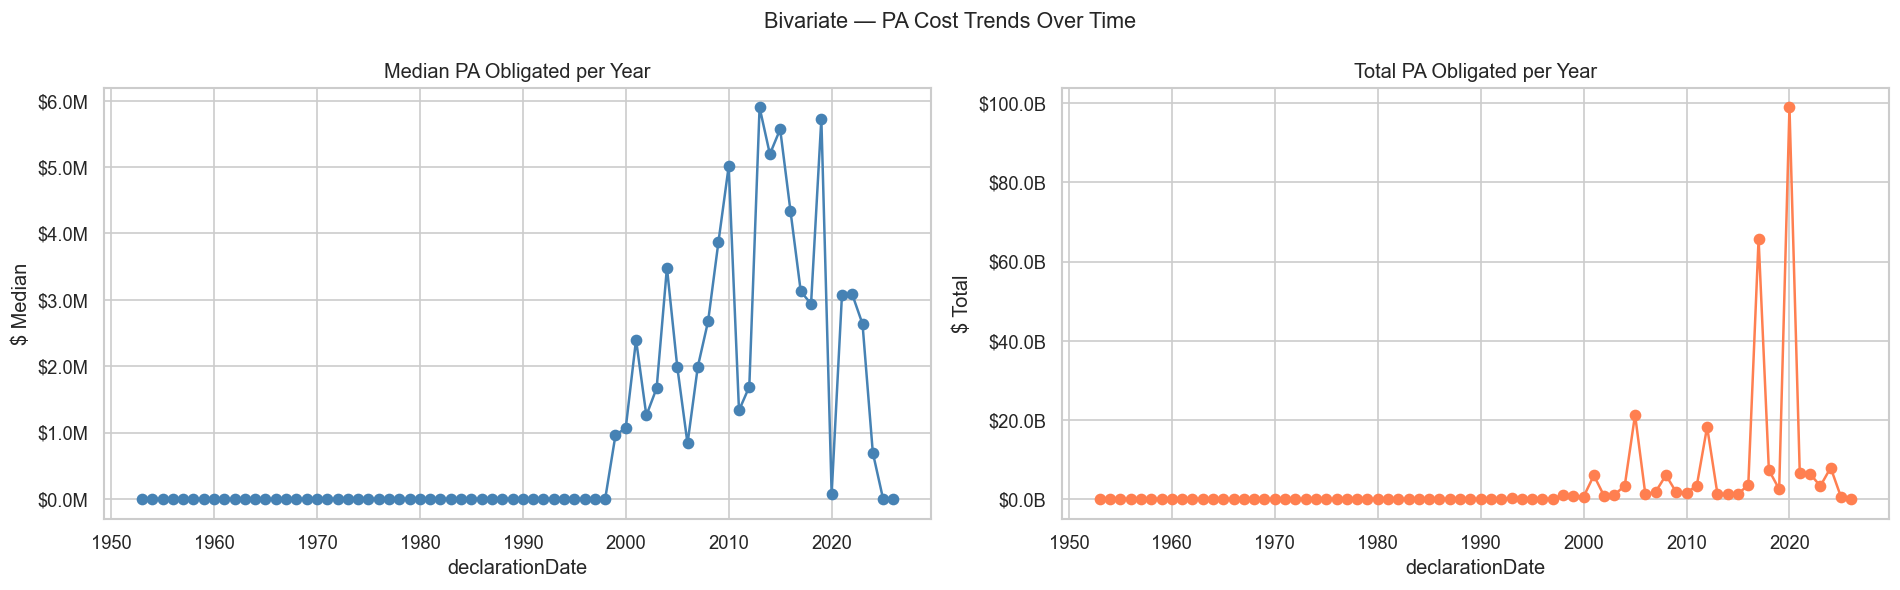

In [31]:
# ── 2c. PA cost trend over time ────────────────────────────────────────────
if "declarationDate" in df.columns:
    yearly_cost = (
        df.groupby(df["declarationDate"].dt.year)[target]
        .agg(["median", "sum", "count"])
        .rename(columns={"median": "Median Cost", "sum": "Total Cost", "count": "Num Disasters"})
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    yearly_cost["Median Cost"].plot(ax=axes[0], color="steelblue", marker="o")
    axes[0].set_title("Median PA Obligated per Year")
    axes[0].set_ylabel("$ Median")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

    yearly_cost["Total Cost"].plot(ax=axes[1], color="coral", marker="o")
    axes[1].set_title("Total PA Obligated per Year")
    axes[1].set_ylabel("$ Total")
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e9:.1f}B"))

    plt.suptitle("Bivariate — PA Cost Trends Over Time", fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 3. Multivariate Analysis
How combinations of features interact and correlate with each other and the target.

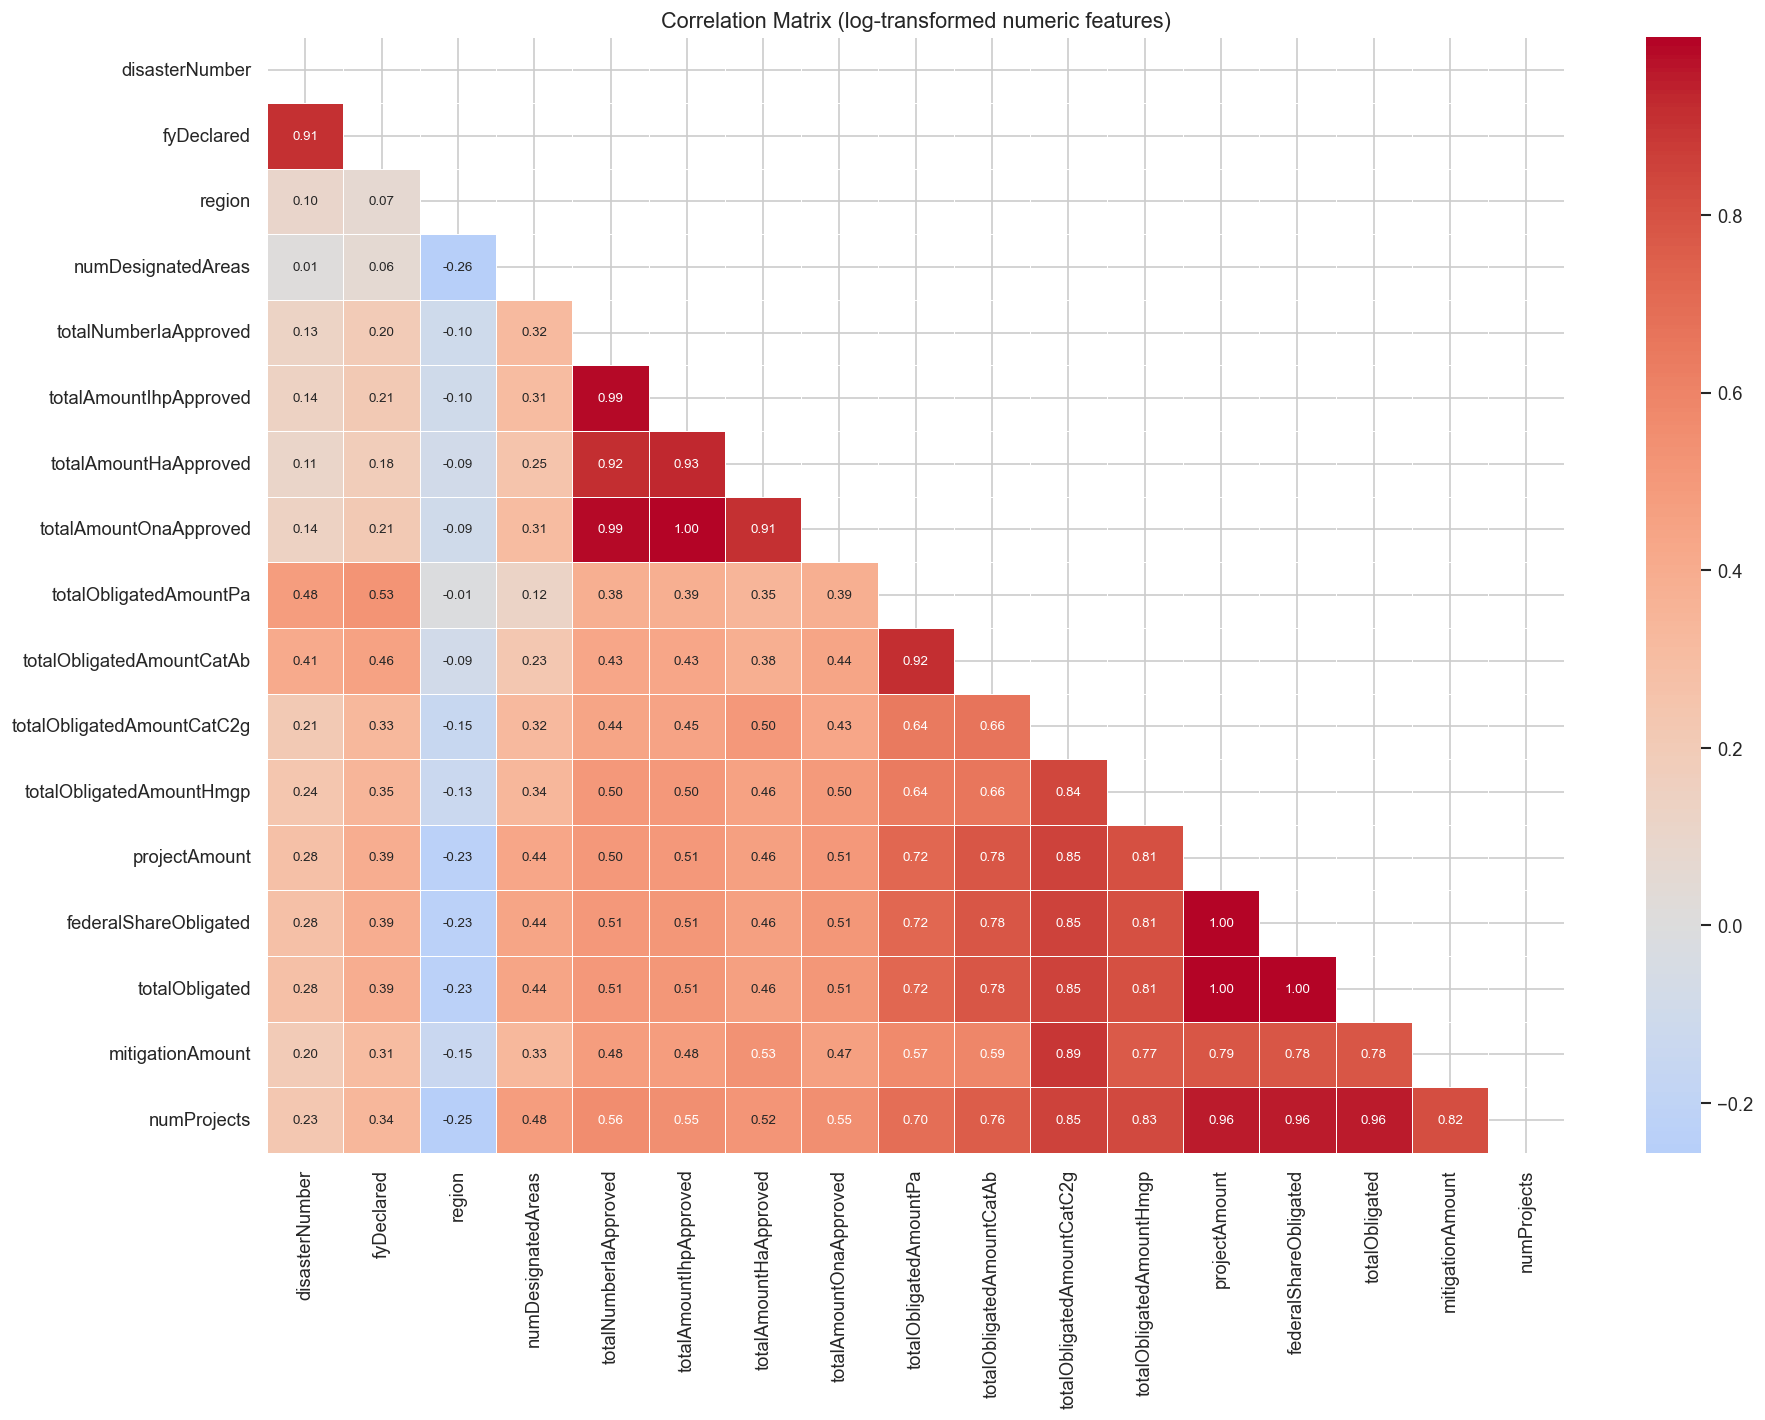


Top correlations with target (totalObligatedAmountPa):
totalObligatedAmountCatAb    0.92
federalShareObligated        0.72
totalObligated               0.72
projectAmount                0.72
numProjects                  0.70
totalObligatedAmountCatC2g   0.64
totalObligatedAmountHmgp     0.64
mitigationAmount             0.57
fyDeclared                   0.53
disasterNumber               0.48
totalAmountOnaApproved       0.39
totalAmountIhpApproved       0.39
totalNumberIaApproved        0.38
totalAmountHaApproved        0.35
numDesignatedAreas           0.12


In [32]:
# ── 3a. Correlation heatmap (numeric columns) ──────────────────────────────
num_cols = df.select_dtypes(include="number").columns.tolist()

# Use log-transformed values so correlations aren't dominated by extreme outliers
df_log = df[num_cols].apply(lambda x: np.log1p(x.clip(lower=0)))
corr = df_log.corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show only lower triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8},
)
ax.set_title("Correlation Matrix (log-transformed numeric features)", fontsize=13)
plt.tight_layout()
plt.show()

# Print top correlations with target
print("\nTop correlations with target (totalObligatedAmountPa):")
target_corr = corr[target].drop(target).abs().sort_values(ascending=False)
print(target_corr.head(15).to_string())

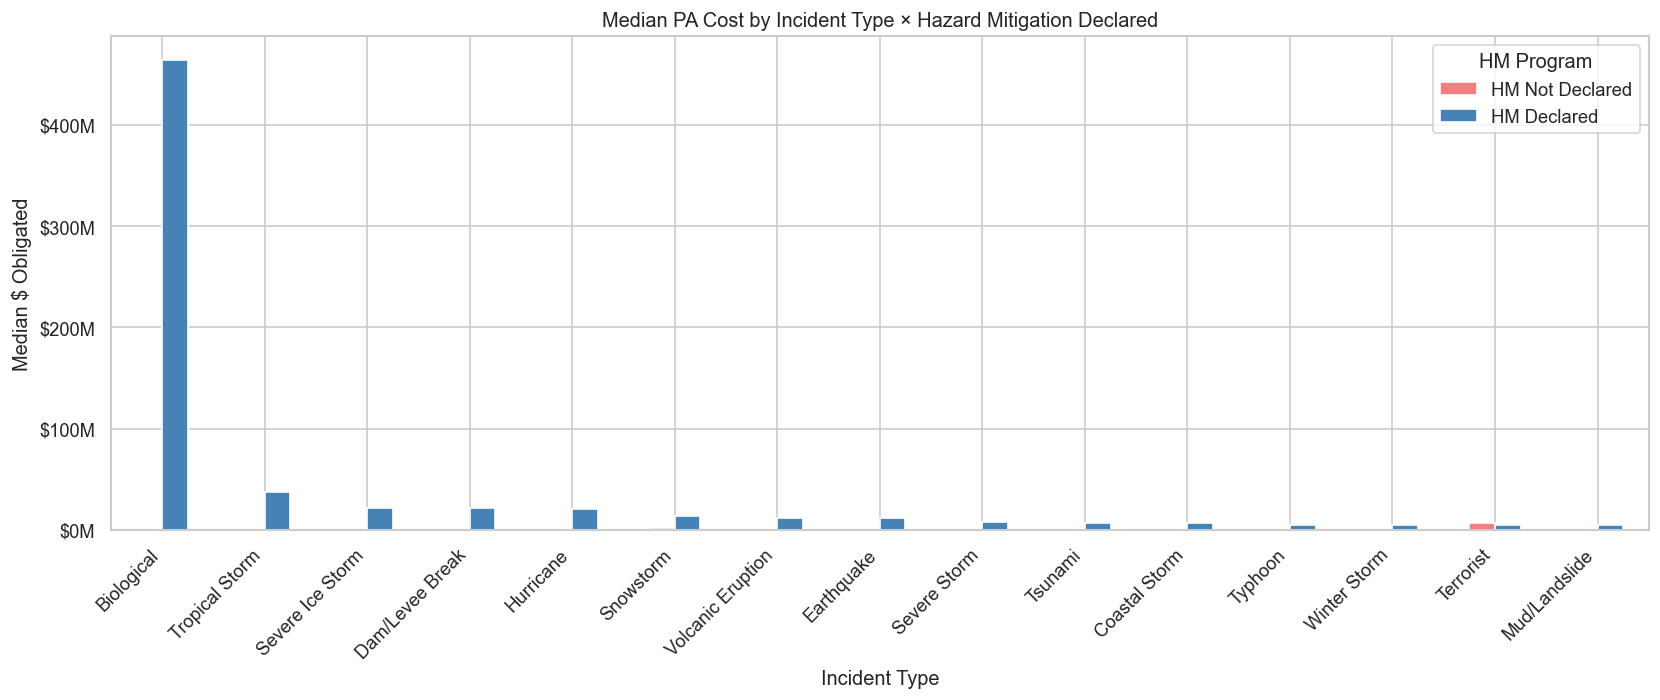

In [33]:
# ── 3b. PA cost by incident type × program declared ────────────────────────
if "incidentType" in df.columns and "hmProgramDeclared" in df.columns:
    pivot = (
        df.groupby(["incidentType", "hmProgramDeclared"])[target]
        .median()
        .unstack()
        .sort_values(by=True, ascending=False)
        .head(15)
    )
    pivot.columns = ["HM Not Declared", "HM Declared"]

    pivot.plot(kind="bar", figsize=(14, 6), color=["lightcoral", "steelblue"], edgecolor="white")
    plt.title("Median PA Cost by Incident Type × Hazard Mitigation Declared")
    plt.ylabel("Median $ Obligated")
    plt.xlabel("Incident Type")
    plt.xticks(rotation=45, ha="right")
    plt.gca().yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
    )
    plt.legend(title="HM Program")
    plt.tight_layout()
    plt.show()

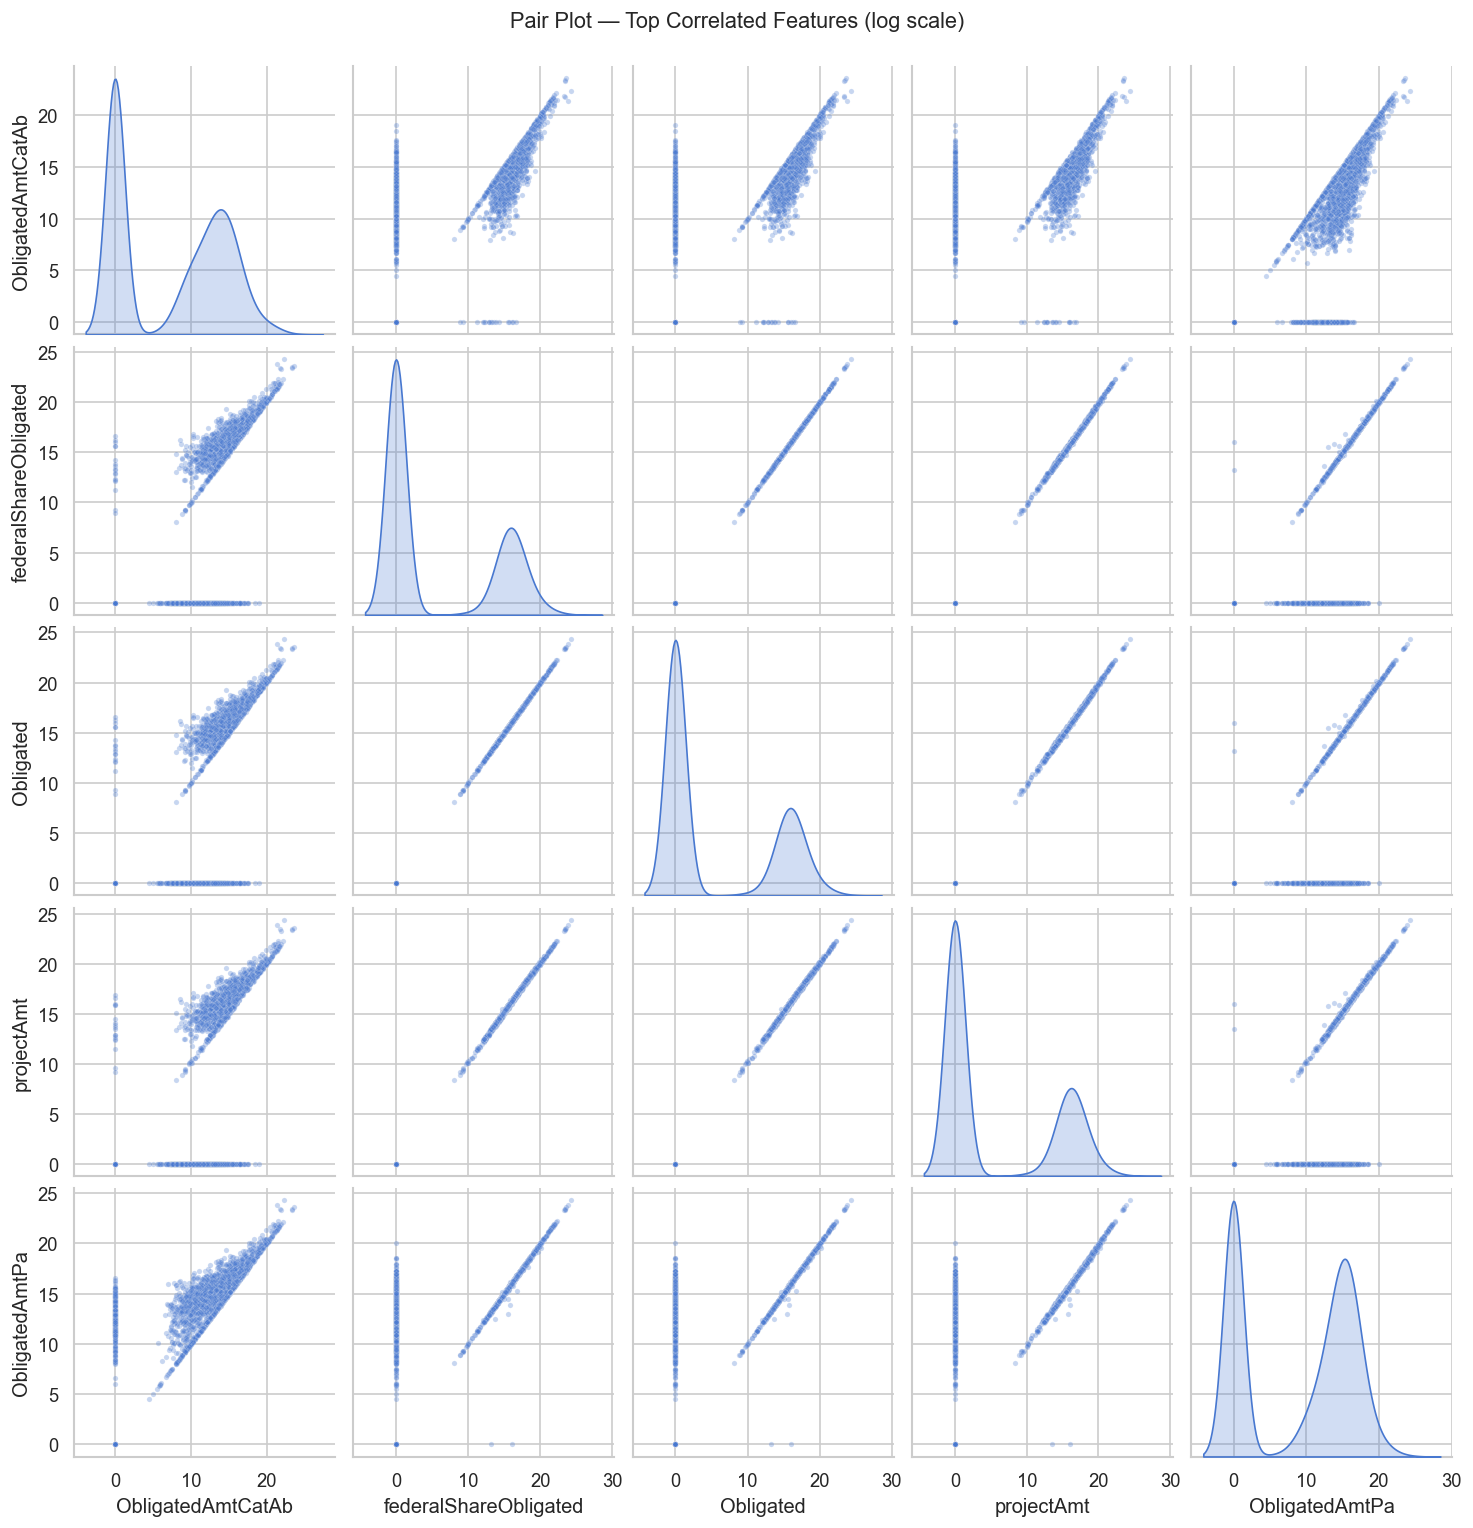

In [34]:
# ── 3c. Pair plot — top correlated features with target ────────────────────
top_features = (
    corr[target].drop(target).abs()
    .sort_values(ascending=False)
    .head(4)
    .index.tolist()
)
pair_cols = top_features + [target]

df_pair = df[pair_cols].apply(lambda x: np.log1p(x.clip(lower=0))).dropna()
df_pair.columns = [c.replace("total", "").replace("Amount", "Amt") for c in df_pair.columns]

g = sns.pairplot(df_pair, diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10}, height=2.5)
g.figure.suptitle("Pair Plot — Top Correlated Features (log scale)", y=1.02, fontsize=13)
plt.show()

In [35]:
# ── 3d. Feature engineering signals — summary table ───────────────────────
print("=" * 65)
print("FEATURE ENGINEERING RECOMMENDATIONS FROM EDA")
print("=" * 65)

num_cols = df.select_dtypes(include="number").columns
skew = df[num_cols].skew().sort_values(ascending=False)
print("\n1. HIGH SKEW (log-transform recommended):")
print(skew[skew.abs() > 1].to_string())

print("\n2. MISSING VALUES TO IMPUTE:")
missing = df.isnull().sum()
print(missing[missing > 0].to_string() if not missing[missing > 0].empty else "None")

print("\n3. LOW VARIANCE COLUMNS (consider dropping):")
low_var = df[num_cols].std()[df[num_cols].std() < 1]
print(low_var.to_string() if not low_var.empty else "None")

print("\n4. STRONG CORRELATIONS WITH TARGET (candidate features):")
print(corr[target].drop(target).abs().sort_values(ascending=False).head(10).to_string())

FEATURE ENGINEERING RECOMMENDATIONS FROM EDA

1. HIGH SKEW (log-transform recommended):
mitigationAmount             45.61
totalObligatedAmountCatC2g   41.69
totalAmountHaApproved        39.80
totalAmountIhpApproved       36.35
totalObligatedAmountHmgp     31.94
projectAmount                31.01
totalObligatedAmountCatAb    30.51
federalShareObligated        29.89
totalObligated               29.86
totalObligatedAmountPa       29.71
totalAmountOnaApproved       24.71
totalNumberIaApproved        20.57
numProjects                  10.24
numDesignatedAreas            4.62

2. MISSING VALUES TO IMPUTE:
None

3. LOW VARIANCE COLUMNS (consider dropping):
None

4. STRONG CORRELATIONS WITH TARGET (candidate features):
totalObligatedAmountCatAb    0.92
federalShareObligated        0.72
totalObligated               0.72
projectAmount                0.72
numProjects                  0.70
totalObligatedAmountCatC2g   0.64
totalObligatedAmountHmgp     0.64
mitigationAmount             0.57
fyDecl